# Notebook 5 — Modélisation et reconstitution 1980–2003
## Régression pour estimer les intensités manquantes

---

## Objectif

Ce notebook apprend la relation `pluie journalière → intensité max` sur la période  
2004–2014 (où les deux sources existent), puis **applique** cette relation aux années  
1980–2003 pour reconstituer les intensités manquantes du pluviographe.

### Principe de la modélisation

On modélise la transformation : $\log(1 + I_{max}) = f(\text{pluie}, \text{mois})$  

La transformation log est utilisée car :
- La distribution des intensités est **log-normale** (forte asymétrie)
- Elle améliore la **linéarité** de la relation avec la pluie
- Elle rend les résidus plus **normaux** (condition pour la régression)

### Modèles testés (validation croisée 5-fold)

| Modèle | Avantage |
|--------|----------|
| LinearRegression | Simple, interprétable |
| RandomForestRegressor | Capture les non-linéarités |
| GradientBoostingRegressor | Meilleure précision en général |

### Livrable

| Fichier | Contenu |
|---------|--------|
| `data/serie_complete.csv` | `[date, intensite_max_mm_h, source, pluie_mm]` |

 avec `source` = `observé` (2004–2014) ou `reconstitué` (1980–2003)

---
**Auteur :** AY2K  
**Encadreur :** Prof. Titembaye Donald  
**Établissement :** École Polytechnique de Lomé (EPL)  
**Projet :** Modélisation des courbes IDF — Station de Kara, Nord Togo  

## 0. Configuration et imports

In [1]:
import os
import warnings

warnings.filterwarnings('ignore')

NB = 'n5'
FIG_DIR = f'figures/{NB}'
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Répertoire figures : {FIG_DIR}')

Répertoire figures : figures/n5


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, learning_curve
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.6,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'figure.dpi':       100,
})

print('Imports chargés')

Imports chargés


---
## Section 1 — Chargement des données

In [3]:
# Tableau d'entraînement (n4) : pluie vs intensité max sur la période commune
df_train = pd.read_csv('data/tableau_entrainement.csv', parse_dates=['date'])

# Pluviomètre complet (n3) : pluies journalières 1980–2014
df_pm = pd.read_csv('data/pluviometre_clean.csv', parse_dates=['date'])

print(f'Tableau entraînement : {len(df_train)} lignes')
print(f'Période train        : {df_train.date.min().date()} → {df_train.date.max().date()}')
print(f'Pluviomètre complet  : {len(df_pm)} lignes')
print(f'Période PM           : {df_pm.date.min().date()} → {df_pm.date.max().date()}')

Tableau entraînement : 617 lignes
Période train        : 2004-06-03 → 2014-10-31
Pluviomètre complet  : 8182 lignes
Période PM           : 1980-01-06 → 2014-12-31


---
## Section 2 — Préparation des features

### Features construites

| Feature | Description | Justification |
|---------|-------------|---------------|
| `pluie_mm` | Pluie journalière brute | Variable explicative principale |
| `log_pluie` | `log(1 + pluie_mm)` | Améliore la linéarité (distribution log-normale) |
| `mois_sin` | `sin(2π × mois / 12)` | Encodage cyclique du mois (décembre→janvier) |
| `mois_cos` | `cos(2π × mois / 12)` | Complément de l'encodage cyclique |

### Target

| Target | Description |
|--------|-------------|
| `log_imax` | `log(1 + intensite_max_mm_h)` — on modélise en log pour better fitting |

### Filtrage

On ne conserve que les **jours pluvieux** (`pluie_mm > 0`) car les jours sans pluie  
n'ont pas d'intensité mesurée par le pluviographe.

In [4]:
df_model = df_train.copy()
df_model = df_model[df_model.pluie_mm > 0].copy()  # Jours pluvieux uniquement

# Features
df_model['log_pluie'] = np.log1p(df_model['pluie_mm'])
df_model['mois_sin']  = np.sin(2 * np.pi * df_model['mois'] / 12)
df_model['mois_cos']  = np.cos(2 * np.pi * df_model['mois'] / 12)
df_model['log_imax']  = np.log1p(df_model['intensite_max_mm_h'])

FEATURES = ['pluie_mm', 'log_pluie', 'mois_sin', 'mois_cos']
TARGET   = 'log_imax'

X = df_model[FEATURES].values
y = df_model[TARGET].values

print(f'Échantillon d\'entraînement : {len(X)} jours pluvieux')
print(f'Features : {FEATURES}')
print(f'Target   : {TARGET} = log(1 + intensite_max_mm_h)')

Échantillon d'entraînement : 514 jours pluvieux
Features : ['pluie_mm', 'log_pluie', 'mois_sin', 'mois_cos']
Target   : log_imax = log(1 + intensite_max_mm_h)


---
## Section 3 — Entraînement et comparaison des modèles

On utilise la **validation croisée 5-fold** pour comparer les modèles de manière  
objective, sans surapprentissage. Les métriques sont :
- **R²** : proportion de la variance expliquée (1 = parfait, 0 = rien)
- **RMSE** : erreur quadratique moyenne (en log-espace)

In [5]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

resultats = []
for nom, modele in models.items():
    r2_scores   = cross_val_score(modele, X, y, cv=cv, scoring='r2')
    rmse_scores = np.sqrt(-cross_val_score(modele, X, y, cv=cv, scoring='neg_mean_squared_error'))
    resultats.append({
        'Modèle': nom,
        'R² moyen': r2_scores.mean(),
        'R² std':   r2_scores.std(),
        'RMSE moyen': rmse_scores.mean(),
        'RMSE std':   rmse_scores.std()
    })
    print(f'{nom}: R²={r2_scores.mean():.3f} ± {r2_scores.std():.3f} | '
          f'RMSE={rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}')

df_resultats = pd.DataFrame(resultats)
print(f'\n=== Tableau comparatif ===')
print(df_resultats.to_string(index=False))

LinearRegression: R²=0.005 ± 0.017 | RMSE=0.948 ± 0.096
RandomForest: R²=-0.161 ± 0.077 | RMSE=1.022 ± 0.094
GradientBoosting: R²=-0.093 ± 0.050 | RMSE=0.992 ± 0.091

=== Tableau comparatif ===
          Modèle  R² moyen   R² std  RMSE moyen  RMSE std
LinearRegression  0.004783 0.017407    0.947856  0.095909
    RandomForest -0.161149 0.077010    1.022049  0.093671
GradientBoosting -0.092587 0.049809    0.991922  0.090965


In [6]:
# Sélection du meilleur modèle par R² moyen
best_name = df_resultats.loc[df_resultats['R² moyen'].idxmax(), 'Modèle']
print(f'Meilleur modèle sélectionné : {best_name}')

best_model = models[best_name]
best_model.fit(X, y)

# Évaluation sur tout l'ensemble
y_pred = best_model.predict(X)
r2_full = r2_score(y, y_pred)
rmse_full = np.sqrt(mean_squared_error(y, y_pred))
print(f'R² (full train)  : {r2_full:.3f}')
print(f'RMSE (full train): {rmse_full:.3f}')

# Avertissement si R² faible
if r2_full < 0.5:
    print('\nAVERTISSEMENT: R² < 0.5 — la transformation log est déjà appliquée.')
    print('Les résultats sont à interpréter avec prudence.')

Meilleur modèle sélectionné : LinearRegression
R² (full train)  : 0.029
RMSE (full train): 0.942

AVERTISSEMENT: R² < 0.5 — la transformation log est déjà appliquée.
Les résultats sont à interpréter avec prudence.


---
## Section 4 — Figures

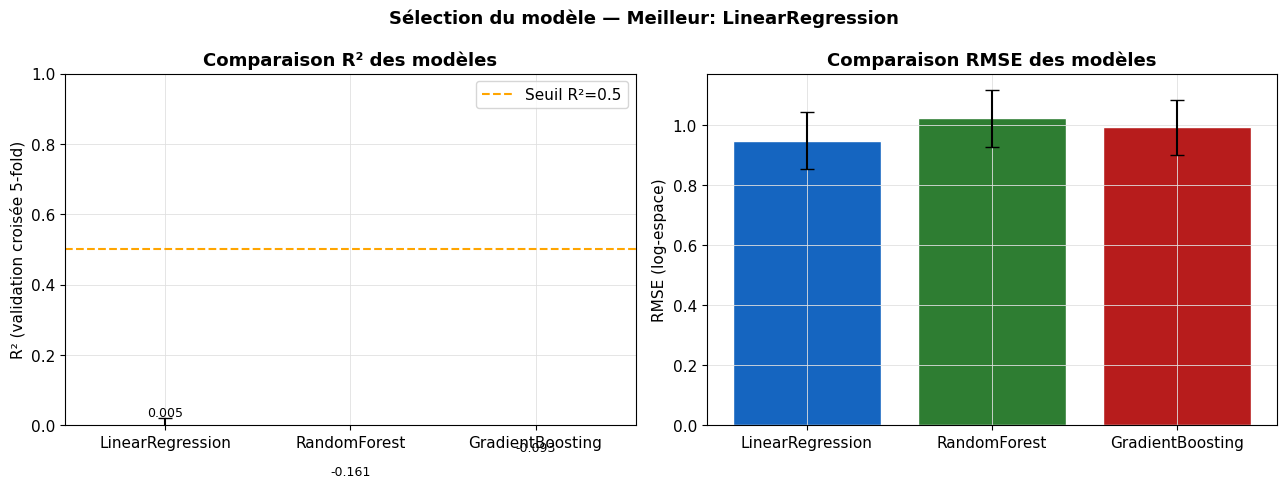

fig1 sauvegardée


In [7]:
# ==============================================================================
# FIGURE 1 — Comparaison des modèles
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#1565C0', '#2E7D32', '#B71C1C']

# R²
ax = axes[0]
bars = ax.bar(df_resultats['Modèle'], df_resultats['R² moyen'], color=colors,
              yerr=df_resultats['R² std'], capsize=5, edgecolor='white')
ax.set_ylabel('R² (validation croisée 5-fold)')
ax.set_title('Comparaison R² des modèles', fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='orange', linestyle='--', label='Seuil R²=0.5')
ax.legend()
for bar, val in zip(bars, df_resultats['R² moyen']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.3f}', ha='center', fontsize=9)

# RMSE
ax2 = axes[1]
bars2 = ax2.bar(df_resultats['Modèle'], df_resultats['RMSE moyen'], color=colors,
                yerr=df_resultats['RMSE std'], capsize=5, edgecolor='white')
ax2.set_ylabel('RMSE (log-espace)')
ax2.set_title('Comparaison RMSE des modèles', fontweight='bold')

plt.suptitle(f'Sélection du modèle — Meilleur: {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig1 sauvegardée')

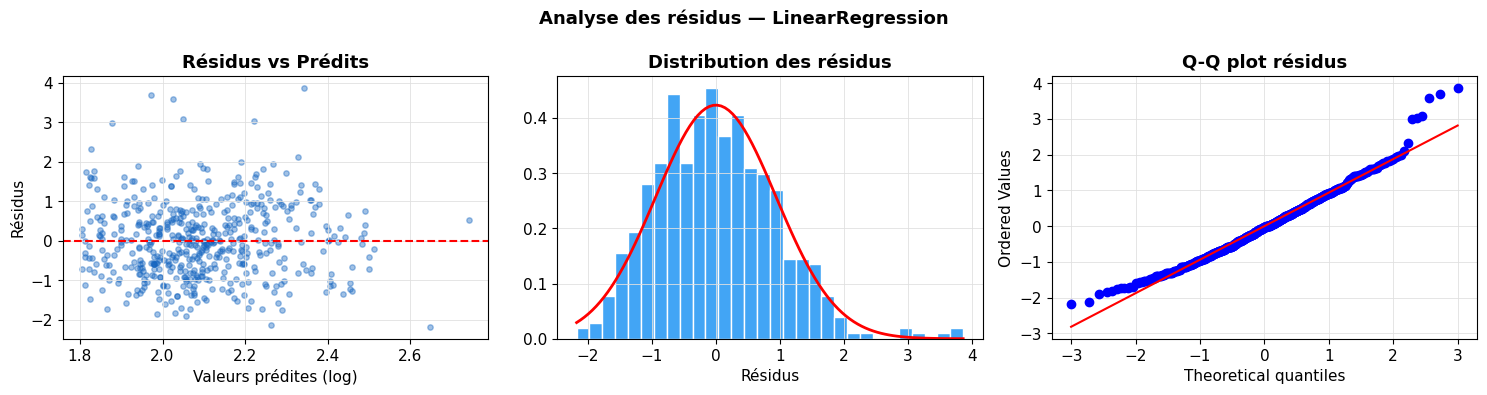

fig2 sauvegardée


In [8]:
# ==============================================================================
# FIGURE 2 — Analyse des résidus
# ==============================================================================

residus = y - y_pred
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Résidus vs prédits
axes[0].scatter(y_pred, residus, alpha=0.4, s=15, color='#1565C0')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valeurs prédites (log)')
axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus vs Prédits', fontweight='bold')

# Distribution des résidus
axes[1].hist(residus, bins=30, color='#42A5F5', edgecolor='white', density=True)
xr = np.linspace(residus.min(), residus.max(), 100)
axes[1].plot(xr, sp_stats.norm.pdf(xr, residus.mean(), residus.std()), 'r-', lw=2)
axes[1].set_xlabel('Résidus')
axes[1].set_title('Distribution des résidus', fontweight='bold')

# Q-Q plot
sp_stats.probplot(residus, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot résidus', fontweight='bold')

plt.suptitle(f'Analyse des résidus — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_residus.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig2 sauvegardée')

In [9]:
# ==============================================================================
# Reconstitution des intensités sur toute la période
# ==============================================================================
#
# Logique :
# 1. Prendre toutes les données du pluviomètre (1980–2014)
# 2. Filtrer les jours pluvieux (pluie > 0)
# 3. Construire les mêmes features que pour l'entraînement
# 4. Appliquer le modèle pour prédire log(1 + intensite)
# 5. Retransformer avec expm1 pour obtenir l'intensité en mm/h
# 6. Marquer chaque jour comme 'observé' (2004–2014) ou 'reconstitué' (1980–2003)

df_pm_full = df_pm.copy()
df_pm_full = df_pm_full[df_pm_full.pluie_mm > 0].copy()
df_pm_full['log_pluie'] = np.log1p(df_pm_full['pluie_mm'])
df_pm_full['mois'] = df_pm_full['date'].dt.month
df_pm_full['mois_sin'] = np.sin(2 * np.pi * df_pm_full['mois'] / 12)
df_pm_full['mois_cos'] = np.cos(2 * np.pi * df_pm_full['mois'] / 12)

# Prédiction
X_full = df_pm_full[FEATURES].values
y_pred_full_log = best_model.predict(X_full)
df_pm_full['intensite_reconstituee'] = np.expm1(y_pred_full_log)

# Marquage de la source
dates_observees = set(df_train['date'].dt.date)
df_pm_full['source'] = df_pm_full['date'].dt.date.apply(
    lambda d: 'observé' if d in dates_observees else 'reconstitué'
)

print(f'Total jours pluvieux     : {len(df_pm_full)}')
print(df_pm_full['source'].value_counts().to_string())

Total jours pluvieux     : 3012
source
reconstitué    2498
observé         514


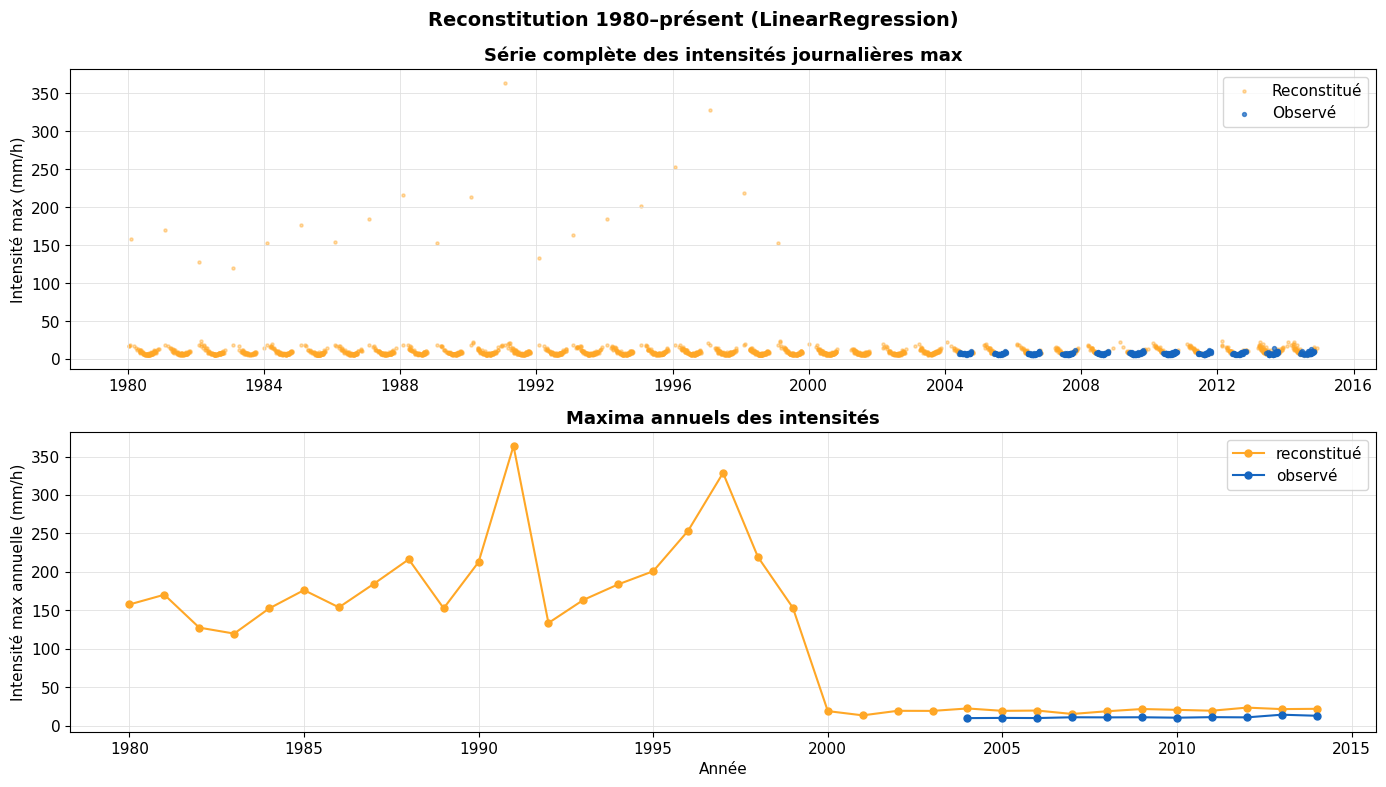

fig3 sauvegardée


In [10]:
# ==============================================================================
# FIGURE 3 — Série complète 1980–présent
# ==============================================================================

df_obs = df_pm_full[df_pm_full.source == 'observé']
df_rec = df_pm_full[df_pm_full.source == 'reconstitué']

# Maxima annuels
df_pm_full['annee'] = df_pm_full['date'].dt.year
max_ann = df_pm_full.groupby(['annee', 'source'])['intensite_reconstituee'].max().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Série journalière
ax = axes[0]
ax.scatter(df_rec.date, df_rec.intensite_reconstituee, s=5, alpha=0.4,
           color='#FFA726', label='Reconstitué')
ax.scatter(df_obs.date, df_obs.intensite_reconstituee, s=8, alpha=0.7,
           color='#1565C0', label='Observé')
ax.set_ylabel('Intensité max (mm/h)')
ax.set_title('Série complète des intensités journalières max', fontweight='bold')
ax.legend()

# Maxima annuels
ax2 = axes[1]
for src, col in [('reconstitué', '#FFA726'), ('observé', '#1565C0')]:
    sub = max_ann[max_ann.source == src]
    if len(sub) > 0:
        ax2.plot(sub.annee, sub.intensite_reconstituee, 'o-', color=col,
                 label=src, linewidth=1.5, markersize=5)
ax2.set_xlabel('Année')
ax2.set_ylabel('Intensité max annuelle (mm/h)')
ax2.set_title('Maxima annuels des intensités', fontweight='bold')
ax2.legend()

plt.suptitle(f'Reconstitution 1980–présent ({best_name})', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_serie_reconstituee.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig3 sauvegardée')

/home/kevin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/home/kevin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/home/kevin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/home/kevin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


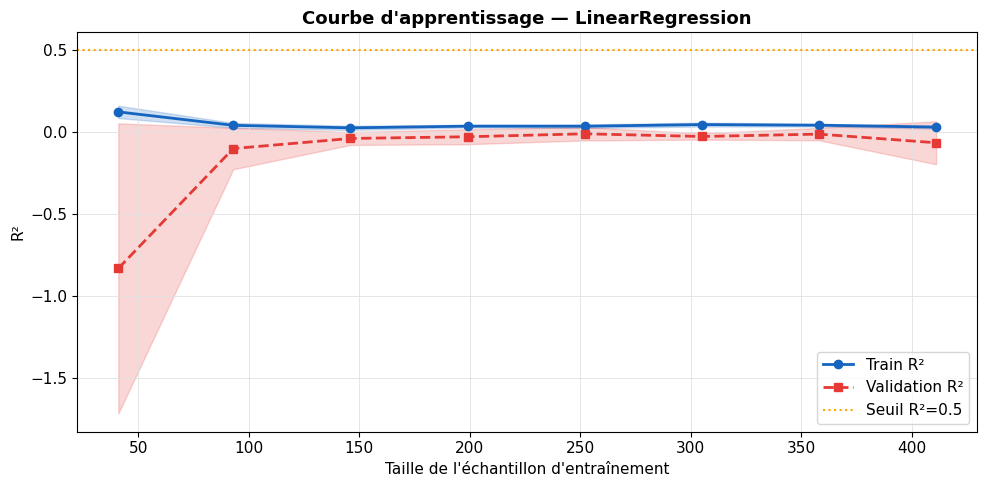

fig4 sauvegardée


In [11]:
# ==============================================================================
# FIGURE 4 — Courbe d'apprentissage
# ==============================================================================

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='r2'
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#1565C0',
        label='Train R²', linewidth=2)
ax.fill_between(train_sizes,
                train_scores.mean(axis=1)-train_scores.std(axis=1),
                train_scores.mean(axis=1)+train_scores.std(axis=1),
                alpha=0.2, color='#1565C0')
ax.plot(train_sizes, val_scores.mean(axis=1), 's--', color='#E53935',
        label='Validation R²', linewidth=2)
ax.fill_between(train_sizes,
                val_scores.mean(axis=1)-val_scores.std(axis=1),
                val_scores.mean(axis=1)+val_scores.std(axis=1),
                alpha=0.2, color='#E53935')
ax.axhline(0.5, color='orange', linestyle=':', label='Seuil R²=0.5')
ax.set_xlabel('Taille de l\'échantillon d\'entraînement')
ax.set_ylabel('R²')
ax.set_title(f'Courbe d\'apprentissage — {best_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig4_validation_croisee.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig4 sauvegardée')

---
## Section 5 — Export de la série complète

In [12]:
# Construction du CSV final
df_serie = df_pm_full[['date', 'intensite_reconstituee', 'source']].copy()
df_serie.columns = ['date', 'intensite_max_mm_h', 'source']
# Ajout de la pluie_mm
df_serie = df_serie.merge(df_pm[['date', 'pluie_mm']], on='date', how='left')
df_serie = df_serie.sort_values('date').reset_index(drop=True)
df_serie.to_csv('data/serie_complete.csv', index=False)

print(f'data/serie_complete.csv exporté ({len(df_serie)} lignes)')
print(f'Période : {df_serie.date.min().date()} → {df_serie.date.max().date()}')
print(f'\nRépartition des sources :')
print(df_serie['source'].value_counts().to_string())
print(f'\n=== Performances du modèle ({best_name}) ===')
print(df_resultats.loc[df_resultats.Modèle == best_name].to_string(index=False))

data/serie_complete.csv exporté (3012 lignes)
Période : 1980-01-21 → 2014-11-30

Répartition des sources :
source
reconstitué    2498
observé         514

=== Performances du modèle (LinearRegression) ===
          Modèle  R² moyen   R² std  RMSE moyen  RMSE std
LinearRegression  0.004783 0.017407    0.947856  0.095909


---
## Résumé

| Indicateur | Valeur |
|------------|--------|
| Modèle sélectionné | Par R² maximal en CV 5-fold |
| Features | pluie_mm, log_pluie, mois_sin, mois_cos |
| Target | log(1 + intensite_max_mm_h) |
| Période reconstituée | 1980–2003 |
| Période observée | 2004–2014 |
| Livrable | `data/serie_complete.csv` |
| Suivant | `n6_extremes.ipynb` et `n7_courbes_idf.ipynb` |

---
*Fin du Notebook 5*